<a href="https://colab.research.google.com/github/JTiiz/CNN-project/blob/main/Kopie_von_Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download the dependencies

In [ ]:
# Optional: store the hugging face read only key to HF_TOKEN

!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn datasets

%pip install kagglehub

#Transform images into the same format and size

In [ ]:
# =============================================================================
#  Image Normalization — Animals-10 Dataset
#  · Converts to RGB
#  · Resizes to TARGET_SIZE
#  · Saves organized by class in subfolders
# =============================================================================
!pip install -q datasets pillow tqdm

import io
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from datasets import load_dataset
from PIL import Image

# ── Config ────────────────────────────────────────────────────────────────────
TARGET_SIZE  = (90, 90)
DATA_DIR     = Path("/content/animals10/normalized-224")
JPEG_QUALITY = 92
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Loading dataset...")
ds = load_dataset("34data/animal-10", split="train")
print(f"  → {len(ds):,} examples\n")

counters  = defaultdict(int)
failed    = 0

for sample in tqdm(ds, desc="Normalizing", unit="img"):
    try:
        # ✅ bytes → PIL.Image
        img = Image.open(io.BytesIO(sample["image"])).convert("RGB")
        img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

        # Clase: "v12/Real/.../cane/imagen.jpg" → "cane"
        parts = sample["filename"].replace("\\", "/").split("/")
        cls   = parts[-2] if len(parts) >= 2 else "unknown"
        if cls == "unknown":
            raise ValueError(f"Bad filename: {sample['filename']}")

        out_path = DATA_DIR / cls / f"{counters[cls]:06d}.jpg"
        out_path.parent.mkdir(exist_ok=True)
        img.save(out_path, format="JPEG", quality=JPEG_QUALITY)
        counters[cls] += 1

    except Exception as e:
        failed += 1

# ── Reporte ───────────────────────────────────────────────────────────────────
total = sum(counters.values())
print(f"\n{'═'*50}")
print(f"Saved  : {total:,}  |  Failed : {failed:,}")
print(f"\nClass distribution:")
for cls, n in sorted(counters.items(), key=lambda x: -x[1]):
    print(f"  {cls:<20} {n:>6,} images")

print("\nVerification (size + mode):")
for cls in sorted(counters):
    first = next((DATA_DIR / cls).glob("*.jpg"))
    with Image.open(first) as im:
        print(f"  {cls:<20} {im.size}  mode={im.mode}")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

animal-10_0003.parquet:   0%|          | 0.00/12.5M [00:00<?, ?B/s]

animal-10_0012.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

...

animal-10_0027.parquet:   0%|          | 0.00/2.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26177 [00:00<?, ? examples/s]

  → 26,177 examples



Normalizing:   0%|          | 0/26177 [00:00<?, ?img/s]


══════════════════════════════════════════════════
Saved  : 26,177  |  Failed : 0

Class distribution:
  cane                  4,863 images
  ragno                 4,821 images
  gallina               3,098 images
  cavallo               2,623 images
  farfalla              2,112 images
  mucca                 1,865 images
  scoiattolo            1,861 images
  pecora                1,820 images
  gatto                 1,668 images
  elefante              1,446 images

Verification (size + mode):
  cane                 (90, 90)  mode=RGB
  cavallo              (90, 90)  mode=RGB
  elefante             (90, 90)  mode=RGB
  farfalla             (90, 90)  mode=RGB
  gallina              (90, 90)  mode=RGB
  gatto                (90, 90)  mode=RGB
  mucca                (90, 90)  mode=RGB
  pecora               (90, 90)  mode=RGB
  ragno                (90, 90)  mode=RGB
  scoiattolo           (90, 90)  mode=RGB


#Verifing images have same format and size

In [ ]:
from pathlib import Path
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

DATA_DIR = Path("/content/animals10/normalized-224")

sizes   = Counter()
modes   = Counter()
formats = Counter()
errors  = 0

all_images = list(DATA_DIR.rglob("*.jpg"))
print(f"Total images found: {len(all_images):,}\n")

for path in tqdm(all_images, desc="Checking", unit="img"):
    try:
        with Image.open(path) as im:
            sizes[im.size]     += 1
            modes[im.mode]     += 1
            formats[im.format] += 1
    except Exception:
        errors += 1

print(f"\n{'═'*40}")
print(f"Unique sizes   : {dict(sizes)}")
print(f"Unique modes   : {dict(modes)}")
print(f"Unique formats : {dict(formats)}")
print(f"Corrupt files  : {errors}")

# Pass/fail summary
ok = len(sizes) == 1 and sizes.get((224, 224)) and len(modes) == 1 and modes.get("RGB")
print(f"\n{'✅ All images are uniform!' if ok else '❌ Inconsistencies found — check counters above'}")

Total images found: 26,177



Checking:   0%|          | 0/26177 [00:00<?, ?img/s]


════════════════════════════════════════
Unique sizes   : {(90, 90): 26177}
Unique modes   : {'RGB': 26177}
Unique formats : {'JPEG': 26177}
Corrupt files  : 0

❌ Inconsistencies found — check counters above


# EDA (Visualizations)



Directory:           /content/animals10/normalized-224
Total images found:  26,177


Analyzing sample:   0%|          | 0/2000 [00:00<?, ?img/s]


══════════════════════════════════════════════════════════════════════
        ANIMALS-10 DATASET — IMAGE STATISTICS (local folder)
══════════════════════════════════════════════════════════════════════
  Total images in folder     : 26,177
  Images analyzed            : 2,000  (skipped 0)

  Width  — min:   90  max:   90  mean: 90  median: 90
  Height — min:   90  max:   90  mean: 90  median: 90

  Channel means (R, G, B)    : [130.42 126.31 103.66]
  Channel stds  (R, G, B)    : [53.2  53.24 53.3 ]

──────────────────────────────────────────────────────────────────────
  CLASS DISTRIBUTION
──────────────────────────────────────────────────────────────────────
  cane           (dog         )  4,863  ███████████████████████████████████  (18.6%)
  cavallo        (horse       )  2,623  ██████████████████  (10.0%)
  elefante       (elephant    )  1,446  ██████████  ( 5.5%)
  farfalla       (butterfly   )  2,112  ███████████████  ( 8.1%)
  gallina        (chicken     )  3,098  ███████████

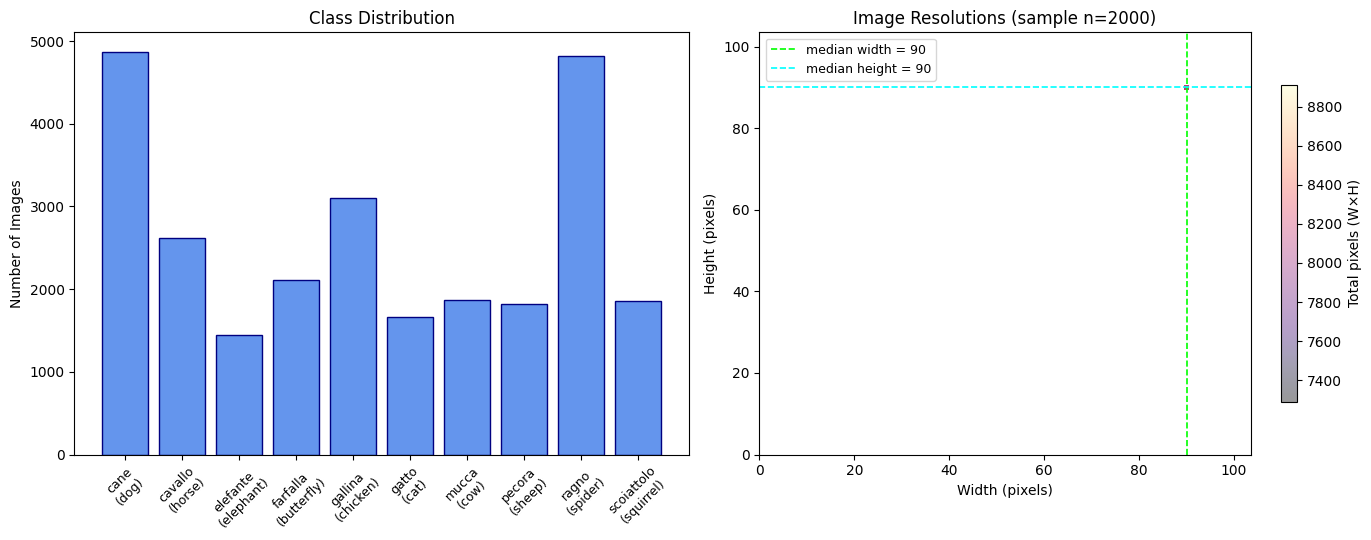

In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ────────────────────────────────────────────────────────────────
DATA_DIR = Path("/content/animals10/normalized-224")
# ────────────────────────────────────────────────────────────────

# Class name translation (Italian → English)
translate = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "ragno": "spider",
    "scoiattolo": "squirrel"
}

# ── Collect all images and extract class names ───────────────────────────────
all_images = list(DATA_DIR.glob("*/*.jpg"))   # use .rglob if needed for deeper nesting

print(f"Directory:           {DATA_DIR}")
print(f"Total images found:  {len(all_images):,}")

if len(all_images) == 0:
    print("No .jpg images found → please check the path")
    # You can add: raise FileNotFoundError(...) or sys.exit() if preferred

# Extract class from parent folder name
def get_class(path: Path) -> str:
    return path.parent.name

all_classes = [get_class(p) for p in all_images]
class_counts = Counter(all_classes)
N_total = len(all_classes)

# ── Sample images for resolution & pixel statistics (fast) ───────────────────
EDA_SAMPLE = 2000
rng = np.random.default_rng(42)
sample_paths = rng.choice(all_images, size=min(EDA_SAMPLE, N_total), replace=False)

widths = []
heights = []
mean_pixels = []
std_pixels = []
skipped = 0

for path in tqdm(sample_paths, desc="Analyzing sample", unit="img"):
    try:
        with Image.open(path) as img:
            img = img.convert('RGB')
            arr = np.asarray(img, dtype=np.float32)

            h, w = arr.shape[:2]
            heights.append(h)
            widths.append(w)

            mean_pixels.append(arr.mean(axis=(0,1)))
            std_pixels.append(arr.std(axis=(0,1)))
    except Exception:
        skipped += 1

widths = np.array(widths)
heights = np.array(heights)
mean_pixels = np.stack(mean_pixels) if mean_pixels else np.array([])
std_pixels  = np.stack(std_pixels)  if std_pixels  else np.array([])

n_valid = len(widths)

print("\n" + "═"*70)
print("        ANIMALS-10 DATASET — IMAGE STATISTICS (local folder)")
print("═"*70)
print(f"  Total images in folder     : {N_total:,}")
print(f"  Images analyzed            : {n_valid:,}  (skipped {skipped})")

if n_valid > 0:
    print(f"\n  Width  — min: {widths.min():4d}  max: {widths.max():4d}  "
          f"mean: {widths.mean():.0f}  median: {np.median(widths):.0f}")
    print(f"  Height — min: {heights.min():4d}  max: {heights.max():4d}  "
          f"mean: {heights.mean():.0f}  median: {np.median(heights):.0f}")

    global_mean = mean_pixels.mean(axis=0)
    global_std  = std_pixels.mean(axis=0)
    print(f"\n  Channel means (R, G, B)    : {global_mean.round(2)}")
    print(f"  Channel stds  (R, G, B)    : {global_std.round(2)}")

# ── Class distribution ───────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("  CLASS DISTRIBUTION")
print(f"{'─'*70}")
max_count = max(class_counts.values(), default=1)

for cls, count in sorted(class_counts.items()):
    eng = translate.get(cls, cls)
    bar = "█" * int((count / max_count) * 35)
    print(f"  {cls:<14} ({eng:<12}) {count:>6,}  {bar}  ({count/N_total:5.1%})")

# ── Plots ────────────────────────────────────────────────────────────────────
if n_valid > 10:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Plot 1: Class distribution
    labels_sorted = sorted(class_counts.keys())
    counts_sorted = [class_counts[c] for c in labels_sorted]
    eng_labels = [f"{c}\n({translate.get(c, c)})" for c in labels_sorted]

    axes[0].bar(eng_labels, counts_sorted, color="cornflowerblue", edgecolor="navy")
    axes[0].set_title("Class Distribution")
    axes[0].set_ylabel("Number of Images")
    axes[0].tick_params(axis='x', rotation=45, labelsize=9)

    # Plot 2: Resolution scatter
    scatter = axes[1].scatter(widths, heights, c=widths*heights, cmap="magma",
                              alpha=0.4, s=12, edgecolors="none")
    axes[1].axvline(np.median(widths), color="lime", ls="--", lw=1.2,
                    label=f"median width = {np.median(widths):.0f}")
    axes[1].axhline(np.median(heights), color="cyan", ls="--", lw=1.2,
                    label=f"median height = {np.median(heights):.0f}")

    axes[1].set_xlabel("Width (pixels)")
    axes[1].set_ylabel("Height (pixels)")
    axes[1].set_title(f"Image Resolutions (sample n={n_valid})")
    axes[1].legend(fontsize=9)

    # Clip axes to avoid extreme outliers
    if n_valid > 20:
        w99 = np.percentile(widths, 99)
        h99 = np.percentile(heights, 99)
        axes[1].set_xlim(0, w99 * 1.15)
        axes[1].set_ylim(0, h99 * 1.15)

    fig.colorbar(scatter, ax=axes[1], label="Total pixels (W×H)", shrink=0.75)

    plt.tight_layout()
    plt.show()

else:
    print("\nSample too small → no plots generated")

#Examples of each class

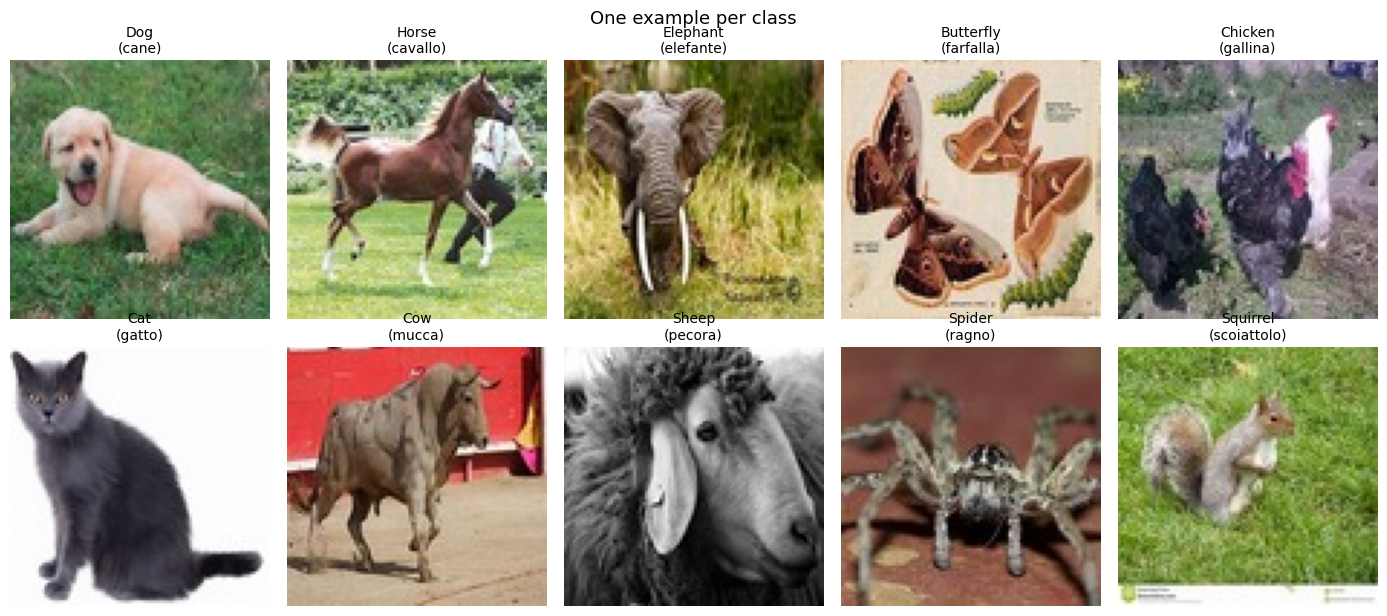

In [ ]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_DIR = Path("/content/animals10/normalized-224")

translate = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "ragno": "spider", "scoiattolo": "squirrel"
}

class_to_images = defaultdict(list)
for p in DATA_DIR.glob("*/*.jpg"):
    class_to_images[p.parent.name].append(p)

selected = {cls: random.choice(imgs) for cls, imgs in class_to_images.items() if imgs}

classes = sorted(selected.keys())

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()

for i, cls in enumerate(classes):
    img = Image.open(selected[cls])
    axes[i].imshow(img)
    axes[i].set_title(f"{translate.get(cls, cls).title()}\n({cls})", fontsize=10)
    axes[i].axis('off')

for ax in axes[len(classes):]:
    ax.axis('off')

plt.tight_layout()
plt.suptitle("One example per class", fontsize=13, y=1.02)
plt.show()

#Make dataset split

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

#we difine a function to make dataset split
DATA_DIR = "/content/animals10/normalized-224"

#input functions parameters
SEED = 42
IMG_SIZE = (90, 90)
BATCH_SIZE = 32

def make_datasets(batch_size):
    print(f"data-dir: {DATA_DIR}")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=batch_size
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=batch_size
    )
    # Get class names from the dataset created by image_dataset_from_directory
    class_names = train_ds.class_names
    # check avaible resorces of CPU and GPU, distribute in a efficient way
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)
    return train_ds, val_ds, class_names



In [ ]:
train_ds_check, val_ds_check, _ = make_datasets(batch_size=32)

print(f"Number of training batches (224x224): {tf.data.experimental.cardinality(train_ds_check).numpy()} batches")
print(f"Number of validation batches (224x224): {tf.data.experimental.cardinality(val_ds_check).numpy()} batches")

data-dir: /content/animals10/normalized-224
Found 26177 files belonging to 10 classes.
Using 20942 files for training.
Found 26177 files belonging to 10 classes.
Using 5235 files for validation.
Number of training batches (224x224): 655 batches
Number of validation batches (224x224): 164 batches


# Define data augumentation functions

In [ ]:
# ashish (temporary)

# ── Data Augmentation (separate method) ───────────────────────────────────────
def build_augmentation():
    """Returns a keras Sequential model for data augmentation."""
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
        layers.RandomBrightness(0.1, seed=SEED),
    ], name="data_augmentation")


In [ ]:
def data_augumentation(inp):
    data_aug = keras.Sequential([
        layers.Rescaling(1./255),
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        # layers.RandomZoom(0.1, seed=SEED),
    ])
    return data_aug(inp)


    #def data_augumentation_test():
    # data_aug = keras.Sequential([
    #     layers.Rescaling(1./255),
    #     layers.RandomFlip("horizontal", seed=SEED),
    #     layers.RandomRotation(0.1, seed=SEED),
    #     # layers.RandomZoom(0.1, seed=SEED),
    # ])
    # return data_aug
    #pass

#Build the model

In [ ]:
def build_baseline_model():
    inputs = keras.Input(shape=(90, 90, 3))
    # x = data_aug(inputs)
    # x = layers.Rescaling(1./255)(x)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
    # x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x) # Apply BatchNormalization to x
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = layers.Conv2D(256, (3,3), padding="same", activation="relu")(x)
    # x = layers.BatchNormalization()
    # x = layers.MaxPooling2D()(x)

    # Block 5
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x) # Apply BatchNormalization to x
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 6
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)

    x = layers.GlobalAveragePooling2D()(x)  # simpler than Flatten, usually better
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="baseline_cnn_v1")


In [ ]:
# Tensorboard
import tensorflow as tf
tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir="logs",
    histogram_freq=1
)

# Train the model

In [ ]:
def train_one_run(learning_rate, batch_size, max_epochs):
    train_ds, val_ds, class_names = make_datasets(batch_size)

    model = build_baseline_model()
    model.summary()
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        tensorboard
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=max_epochs,
        callbacks=callbacks
    )
    return model, history, class_names

#Evaluation graphs

In [ ]:
# generate the evaluation graph

from matplotlib import pyplot as plt

def evaluation_graph(history):
  # Training curves
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))
  axes[0].plot(history.history["loss"], label="Train")
  axes[0].plot(history.history["val_loss"], label="Validation")
  axes[0].set_title("Loss")
  axes[0].set_xlabel("Epoch")
  axes[0].legend()
  axes[0].grid(alpha=0.3)

  axes[1].plot(history.history["accuracy"], label="Train")
  axes[1].plot(history.history["val_accuracy"], label="Validation")
  axes[1].set_title("Accuracy")
  axes[1].set_xlabel("Epoch")
  axes[1].legend()
  axes[1].grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

# Select this cell and from the run menu, select run before. It will execute all the code cells before this.

In [ ]:
# ashish experimentation
a_model, a_history, a_class_names = train_one_run(
    learning_rate=0.01,
    batch_size=32,
    max_epochs=50
)


data-dir: /content/animals10/normalized-224
Found 26177 files belonging to 10 classes.
Using 20942 files for training.
Found 26177 files belonging to 10 classes.
Using 5235 files for validation.


Model: "baseline_cnn_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,082 (2.91 MB)

 Trainable params: 762,570 (2.91 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 164s 219ms/step - accuracy: 0.1894 - loss: 2.2886 - val_accuracy: 0.1836 - val_loss: 2.1957 - learning_rate: 0.0100
Epoch 2/50
449/655 ━━━━━━━━━━━━━━━━━━━━ 36s 179ms/step - accuracy: 0.1792 - loss: 2.2124

In [ ]:
# jesus experimetnation
j_model, j_history, j_class_names = train_one_run(
    learning_rate=0.01,
    batch_size=32*2,
    max_epochs=50
)


data-dir: /content/animals10/normalized-224
Found 26177 files belonging to 10 classes.
Using 20942 files for training.
Found 26177 files belonging to 10 classes.
Using 5235 files for validation.


Model: "baseline_cnn_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,082 (2.91 MB)

 Trainable params: 762,570 (2.91 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 134s 395ms/step - accuracy: 0.2491 - loss: 2.0888 - val_accuracy: 0.2086 - val_loss: 4.6171 - learning_rate: 0.0100
Epoch 2/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 131s 400ms/step - accuracy: 0.4081 - loss: 1.6825 - val_accuracy: 0.4055 - val_loss: 1.6665 - learning_rate: 0.0100
Epoch 3/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 134s 408ms/step - accuracy: 0.4993 - loss: 1.4265 - val_accuracy: 0.4747 - val_loss: 1.5472 - learning_rate: 0.0100
Epoch 4/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 135s 410ms/step - accuracy: 0.5636 - loss: 1.2577 - val_accuracy: 0.5364 - val_loss: 1.3249 - learning_rate: 0.0100
Epoch 5/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 139s 424ms/step - accuracy: 0.6030 - loss: 1.1476 - val_accuracy: 0.5349 - val_loss: 1.3653 - learning_rate: 0.0100
Epoch 6/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 137s 419ms/step - accuracy: 0.6413 - loss: 1.0457 - val_accuracy: 0.6128 - val_loss: 1.1539 - learning_rate: 0.0100
Epoch 7/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 135s 411ms/step - accura

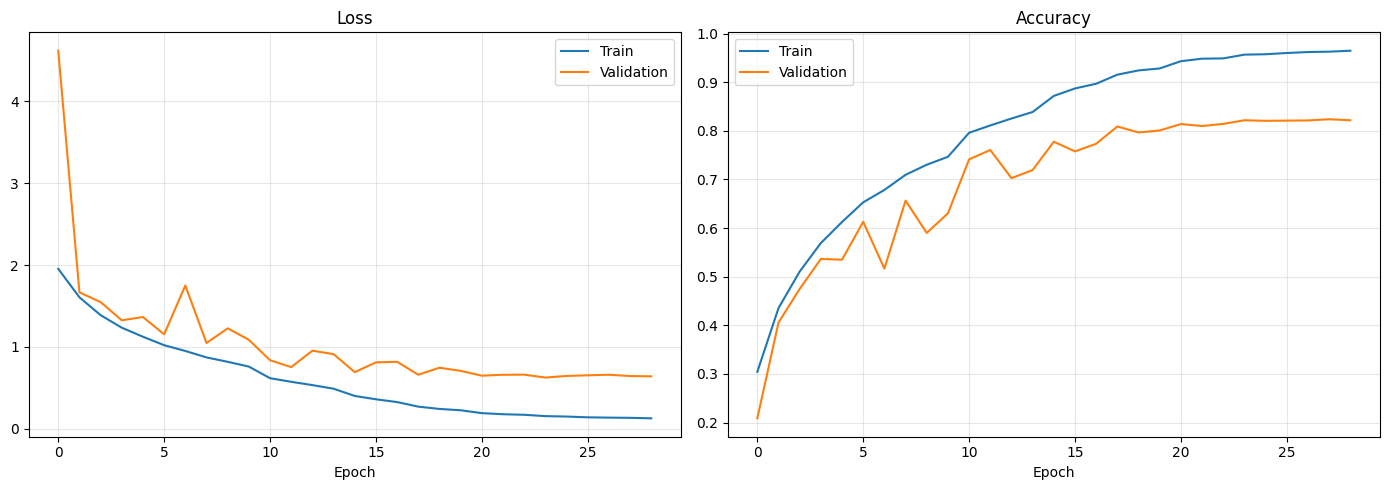

In [ ]:
evaluation_graph(history=j_history)

In [ ]:
# daniel experimentation
d_model, d_history, d_class_names = train_one_run(
    learning_rate=0.001,
    batch_size=16,
    max_epochs=50
)

data-dir: /content/animals10/normalized-224
Found 26177 files belonging to 10 classes.
Using 20942 files for training.
Found 26177 files belonging to 10 classes.
Using 5235 files for validation.


Model: "baseline_cnn_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 90, 90, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 90, 90, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 22, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,082 (2.91 MB)

 Trainable params: 762,570 (2.91 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.2430 - loss: 2.1215 - val_accuracy: 0.2886 - val_loss: 2.2498 - learning_rate: 0.0010
Epoch 2/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.3983 - loss: 1.7031 - val_accuracy: 0.3291 - val_loss: 2.1467 - learning_rate: 0.0010
Epoch 3/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.4712 - loss: 1.4958 - val_accuracy: 0.3075 - val_loss: 2.3739 - learning_rate: 0.0010
Epoch 4/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.5303 - loss: 1.3509 - val_accuracy: 0.4753 - val_loss: 1.5816 - learning_rate: 0.0010
Epoch 5/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.5699 - loss: 1.2471 - val_accuracy: 0.5249 - val_loss: 1.4029 - learning_rate: 0.0010
Epoch 6/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.6036 - loss: 1.1645 - val_accuracy: 0.6164 - val_loss: 1.1266 - learning_rate: 0.0010
Epoch 7/50
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accura

In [ ]:
d_model.save("./model_vanillaCNN_animals.keras")       # folder with: config.json, pytorch_model.bin, etc.
#processor.save_pretrained("./model_vanillaCNN_animals")

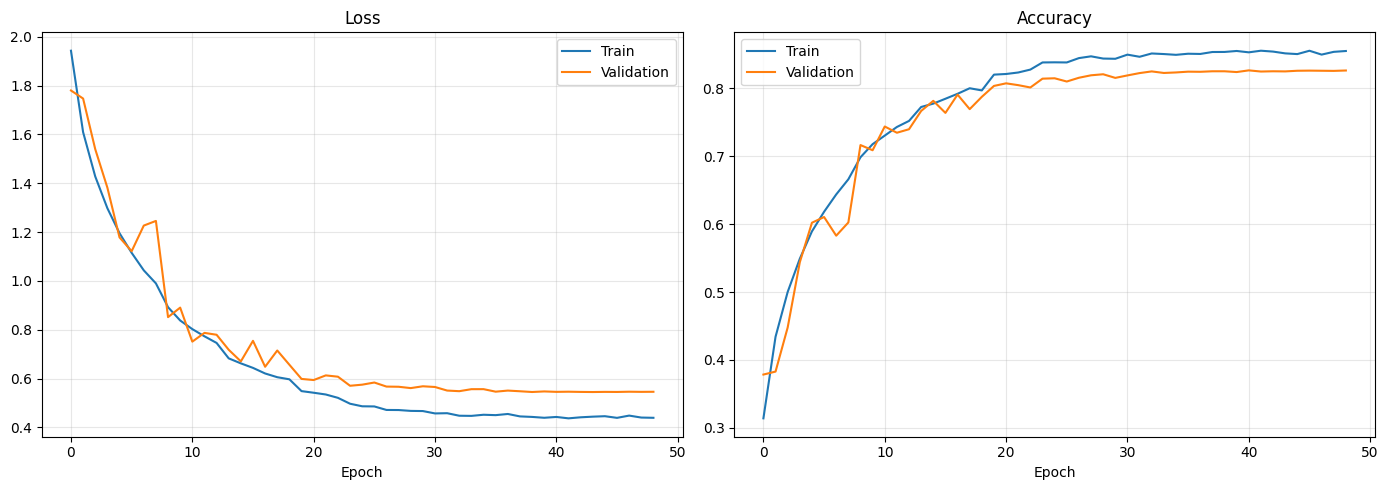

In [ ]:
evaluation_graph(history=d_history)

In [ ]:
# nadya experimentation
n_model, n_history, n_class_names = train_one_run(
    learning_rate=0.001,
    batch_size=32,
    max_epochs=50
)


data-dir: /content/animals10/normalized-224
Found 26177 files belonging to 10 classes.
Using 20942 files for training.
Found 26177 files belonging to 10 classes.
Using 5235 files for validation.


Model: "baseline_cnn_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,082 (2.91 MB)

 Trainable params: 762,570 (2.91 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.2506 - loss: 2.1051 - val_accuracy: 0.1450 - val_loss: 3.0211 - learning_rate: 0.0010
Epoch 2/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4276 - loss: 1.6243 - val_accuracy: 0.4980 - val_loss: 1.4729 - learning_rate: 0.0010
Epoch 3/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5491 - loss: 1.3203 - val_accuracy: 0.3379 - val_loss: 3.5261 - learning_rate: 0.0010
Epoch 4/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6044 - loss: 1.1748 - val_accuracy: 0.6115 - val_loss: 1.1391 - learning_rate: 0.0010
Epoch 5/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6485 - loss: 1.0299 - val_accuracy: 0.6067 - val_loss: 1.2224 - learning_rate: 0.0010
Epoch 6/50
651/655 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6852 - loss: 0.9247
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
655/655 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6853 - loss: 0.

NameError: name 'evaluation_graph' is not defined

In [ ]:
evaluation_graph(history=n_history)

#EfficientNetV2

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

# Configuration
IMG_SIZE = (90, 90)          # EfficientNetV2S default
BATCH_SIZE = 32
NUM_CLASSES = 10               # ← CHANGE THIS to your number of classes
EPOCHS = 10

# Data loading
train_ds = keras.utils.image_dataset_from_directory(
    "/content/animals10/normalized-224",
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    "/content/animals10/normalized-224",
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Apply preprocessing (EfficientNetV2 expects [0, 255] range, but includes its own preprocess)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(  lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

# Load base model
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    pooling="avg"           # global average pooling by default
)

# Freeze the base (feature extraction first)
base_model.trainable = False

# Build model
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train (feature extraction phase)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)



Found 26177 files belonging to 10 classes.
Found 26177 files belonging to 10 classes.
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 154s 121ms/step - accuracy: 0.7588 - loss: 0.8233 - val_accuracy: 0.8878 - val_loss: 0.3531
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - accuracy: 0.8650 - loss: 0.4132 - val_accuracy: 0.9001 - val_loss: 0.3099
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - accuracy: 0.8773 - loss: 0.3829 - val_accuracy: 0.9045 - val_loss: 0.2944
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - accuracy: 0.8816 - loss: 0.3659 - val_accuracy: 0.9085 - val_loss: 0.2799
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - accuracy: 0.8817 - loss: 0.3571 - val_accuracy: 0.9126 - val_loss: 0.2683
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - accuracy: 0.8853 - loss: 0.3441 - val_accuracy: 0.9158 - val_loss: 0.2610
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - accuracy: 0.8833 - loss: 

In [ ]:
model.save('/content/drive/MyDrive/modelos/mi_modelo_animals10_efficientnetv2s.h5')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#ConvNeXt

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.applications.convnext import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import os, zipfile, json

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR       = "/content/animals10/normalized-224"
CHECKPOINT_PATH = "/content/best_convnext.keras"
EXPORT_DIR     = "/content/convnext_animals10"
ZIP_PATH       = "/content/convnext_animals10.zip"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 10
EPOCHS_HEAD = 10     # Train only the head (base frozen)
EPOCHS_FINE = 6      # Fine-tune last N layers of base
UNFREEZE_FROM = -30  # Unfreeze last 30 layers during fine-tuning
LR_HEAD = 5e-4
LR_FINE = 1e-5
PATIENCE    = 3
VAL_SPLIT   = 0.1

# Mixed precision for faster training on GPU/TPU
mixed_precision.set_global_policy("mixed_float16")
print(f"✅ Mixed precision : {mixed_precision.global_policy().name}")
print(f"   GPUs available  : {len(tf.config.list_physical_devices('GPU'))}")

# ─────────────────────────────────────────────────────────────────────────────
#  LABEL MAPPING  (Animals-10 folder names → English)
# ─────────────────────────────────────────────────────────────────────────────
LABEL_MAP = {
    "cane":       "dog",
    "cavallo":    "horse",
    "elefante":   "elephant",
    "farfalla":   "butterfly",
    "gallina":    "chicken",
    "gatto":      "cat",
    "mucca":      "cow",
    "pecora":     "sheep",
    "ragno":      "spider",
    "scoiattolo": "squirrel",
}

# Build index → English name mapping (sorted alphabetically, same as Keras)
raw_classes  = sorted(os.listdir(DATA_DIR))          # folder names
english_names = [LABEL_MAP.get(c, c) for c in raw_classes]
print(f"\n✅ Class mapping  : {dict(zip(raw_classes, english_names))}")

# ─────────────────────────────────────────────────────────────────────────────
#  DATASET  (single split, augmentation only on train)
# ─────────────────────────────────────────────────────────────────────────────
def build_datasets():
    common = dict(
        directory=DATA_DIR,
        label_mode="categorical",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        seed=42,
    )
    train_raw = keras.utils.image_dataset_from_directory(subset="training",   **common)
    val_raw   = keras.utils.image_dataset_from_directory(subset="validation", **common)
    return train_raw, val_raw

train_raw, val_raw = build_datasets()
N_TRAIN = train_raw.cardinality().numpy() * BATCH_SIZE
N_VAL   = val_raw.cardinality().numpy()   * BATCH_SIZE
print(f"\n✅ Dataset   : ~{N_TRAIN:,} train | ~{N_VAL:,} val")

# Data augmentation (applied only to train, inside tf.data pipeline)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

def prepare_train(x, y):
    x = augment(x, training=True)
    return preprocess_input(x), y

def prepare_val(x, y):
    return preprocess_input(x), y

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (train_raw
            .map(prepare_train, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds   = (val_raw
            .map(prepare_val, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

# ─────────────────────────────────────────────────────────────────────────────
#  MODEL
# ─────────────────────────────────────────────────────────────────────────────
base_model = ConvNeXtBase(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    pooling="avg",
)
base_model.trainable = False

inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(256, activation="gelu")(x)       # Extra dense head
x       = layers.Dropout(0.2)(x)
# Cast to float32 before softmax (required with mixed precision)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs, name="ConvNeXtBase_Animals10")
model.summary(line_length=80)

# ─────────────────────────────────────────────────────────────────────────────
#  CALLBACKS
# ─────────────────────────────────────────────────────────────────────────────
def make_callbacks(monitor="val_accuracy"):
    return [
        keras.callbacks.ModelCheckpoint(
            CHECKPOINT_PATH,
            monitor=monitor,
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor=monitor,
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor=monitor,
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

# ─────────────────────────────────────────────────────────────────────────────
#  PHASE 1 — Train head only
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("  PHASE 1 — Head training (base frozen)")
print("═"*60)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_HEAD, weight_decay=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=make_callbacks(),
)

# ─────────────────────────────────────────────────────────────────────────────
#  PHASE 2 — Fine-tuning (unfreeze last layers)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print(f"  PHASE 2 — Fine-tuning (last {abs(UNFREEZE_FROM)} base layers)")
print("═"*60)

base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

frozen   = sum(not l.trainable for l in base_model.layers)
unfrozen = sum(l.trainable     for l in base_model.layers)
print(f"   Frozen layers   : {frozen}")
print(f"   Unfrozen layers : {unfrozen}")

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_FINE, weight_decay=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=make_callbacks(),
)

# ─────────────────────────────────────────────────────────────────────────────
#  METRICS PLOT
# ─────────────────────────────────────────────────────────────────────────────
def merge_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (k_train, k_val), title in zip(
    axes,
    [("loss", "val_loss"), ("accuracy", "val_accuracy")],
    ["Loss", "Accuracy"],
):
    y_train = merge_history(history1, history2, k_train)
    y_val   = merge_history(history1, history2, k_val)
    epochs  = range(1, len(y_train) + 1)
    split   = len(history1.history[k_train])

    ax.plot(epochs, y_train, "o-", label="Train", color="royalblue")
    ax.plot(epochs, y_val,   "o-", label="Val",   color="tomato")
    ax.axvline(split + 0.5, color="gray", linestyle="--", alpha=0.6, label="Fine-tune start")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("ConvNeXtBase — Animals10", fontsize=14)
plt.tight_layout()
plt.savefig("/content/training_metrics.png", dpi=100)
plt.show()

best_val_acc = max(merge_history(history1, history2, "val_accuracy"))
print(f"\n🏆 Best val accuracy : {best_val_acc*100:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
#  SAVE MODEL + LABEL MAP
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs(EXPORT_DIR, exist_ok=True)

# Load the best checkpoint saved during training
best_model = keras.models.load_model(CHECKPOINT_PATH)
best_model.save(os.path.join(EXPORT_DIR, "model.keras"))

# Save label map as JSON
label_info = {
    "index_to_label": {str(i): name for i, name in enumerate(english_names)},
    "label_to_index": {name: i for i, name in enumerate(english_names)},
    "raw_to_english": LABEL_MAP,
    "num_classes": NUM_CLASSES,
    "img_size": list(IMG_SIZE),
}
with open(os.path.join(EXPORT_DIR, "label_map.json"), "w") as f:
    json.dump(label_info, f, indent=2)

# Copy metrics plot
import shutil
shutil.copy("/content/training_metrics.png", EXPORT_DIR)

print(f"✅ Model saved to  : {EXPORT_DIR}")

# ─────────────────────────────────────────────────────────────────────────────
#  ZIP AND DOWNLOAD  (Colab)
# ─────────────────────────────────────────────────────────────────────────────
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(EXPORT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname   = os.path.relpath(full_path, "/content")
            zf.write(full_path, arcname)

print(f"✅ Zipped to        : {ZIP_PATH}")

try:
    from google.colab import files
    files.download(ZIP_PATH)
    print("⬇️  Download started automatically")
except ImportError:
    print(f"ℹ️  Not running in Colab — find your file at: {ZIP_PATH}")

# ─────────────────────────────────────────────────────────────────────────────
#  INFERENCE HELPER
# ─────────────────────────────────────────────────────────────────────────────
def predict(image_path: str, top_k: int = 3) -> dict:
    """
    Predict the animal class of a single image.
    Returns a dict of {animal_name: probability_string}.
    """
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    arr = preprocess_input(np.expand_dims(arr, 0))

    probs   = best_model.predict(arr, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]

    results = {english_names[i]: f"{probs[i]*100:.2f}%" for i in top_idx}

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(keras.utils.load_img(image_path, target_size=IMG_SIZE))
    axes[0].axis("off"); axes[0].set_title("Input image")

    names  = list(results.keys())
    values = [float(v[:-1]) for v in results.values()]
    bars   = axes[1].barh(names, values, color="royalblue")
    axes[1].set_xlabel("Probability (%)")
    axes[1].set_title(f"Top-{top_k} predictions")
    axes[1].bar_label(bars, labels=list(results.values()), padding=4)
    plt.tight_layout(); plt.show()

    return results

# Example usage:
# predict("/path/to/your/image.jpg")

# Later fine-tuning example:
# base_model.trainable = True
# model.compile(optimizer=keras.optimizers.AdamW(1e-5), loss=..., metrics=...)
# model.fit(...)

✅ Mixed precision : mixed_float16
   GPUs available  : 1

✅ Class mapping  : {'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant', 'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat', 'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'}
Found 26177 files belonging to 10 classes.
Using 23560 files for training.
Found 26177 files belonging to 10 classes.
Using 2617 files for validation.

✅ Dataset   : ~23,584 train | ~2,624 val


Model: "ConvNeXtBase_Animals10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)       │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ convnext_base (Functional)        │ (None, 1024)             │    87,566,464 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 1024)             │         4,096 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_2 (Dropout)               │ (None, 1024)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 256)              │       262,400 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_3 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 10)               │         2,570 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 87,835,530 (335.07 MB)

 Trainable params: 267,018 (1.02 MB)

 Non-trainable params: 87,568,512 (334.05 MB)


════════════════════════════════════════════════════════════
  PHASE 1 — Head training (base frozen)
════════════════════════════════════════════════════════════
Epoch 1/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9170 - loss: 0.2971
Epoch 1: val_accuracy improved from -inf to 0.98510, saving model to /content/best_convnext.keras
737/737 ━━━━━━━━━━━━━━━━━━━━ 679s 780ms/step - accuracy: 0.9170 - loss: 0.2969 - val_accuracy: 0.9851 - val_loss: 0.0575 - learning_rate: 5.0000e-04
Epoch 2/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9789 - loss: 0.0847
Epoch 2: val_accuracy did not improve from 0.98510
737/737 ━━━━━━━━━━━━━━━━━━━━ 420s 569ms/step - accuracy: 0.9789 - loss: 0.0847 - val_accuracy: 0.9851 - val_loss: 0.0555 - learning_rate: 5.0000e-04
Epoch 3/10
736/737 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9827 - loss: 0.0646
Epoch 3: val_accuracy improved from 0.98510 to 0.98548, saving model to /content/best_convnext.keras
737/737 ━━━━━━━━━━━━━━━━━

#Vision Transformer (ViT)

✅ Dispositivo : cuda
   GPU          : Tesla T4
   VRAM         : 15.6 GB
   AMP          : True

✅ Dataset      : 26,177 imágenes → Train 23,559 | Val 2,618
   Clases       : ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
/tmp/ipykernel_296/4123622550.py:115: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=USE_AMP)



✅ Parámetros   : 43,279,114 / 85,806,346  (50.4% entrenables)

🚀 Iniciando entrenamiento...



Train:   0%|          | 0/737 [00:00<?, ?batch/s]/tmp/ipykernel_296/4123622550.py:181: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Época  1/10 | Train → loss: 1.0372  acc: 80.48% | Val   → loss: 0.5475  acc: 98.70% | ⏱ 239s


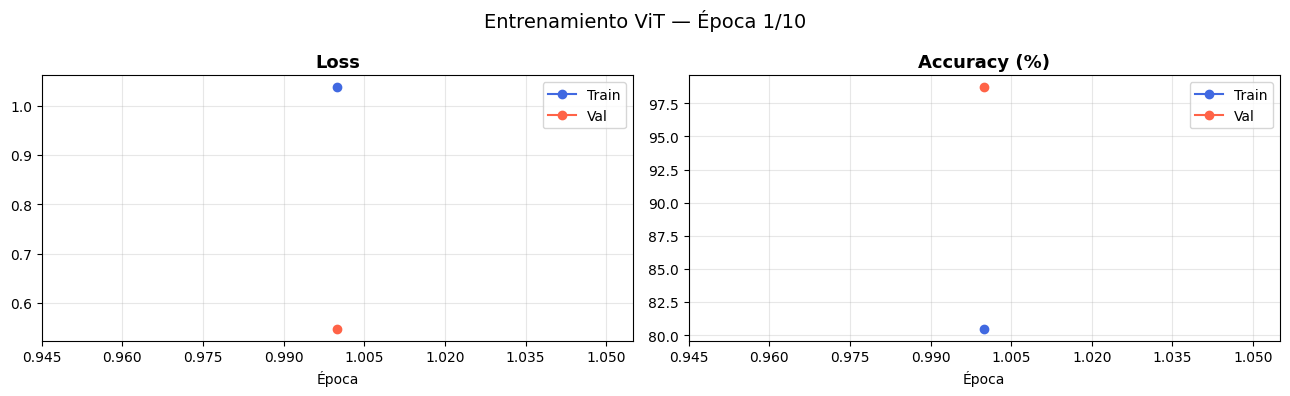

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Checkpoint guardado (val_loss=0.5475)


Época  2/10 | Train → loss: 0.5397  acc: 98.65% | Val   → loss: 0.5376  acc: 98.62% | ⏱ 204s


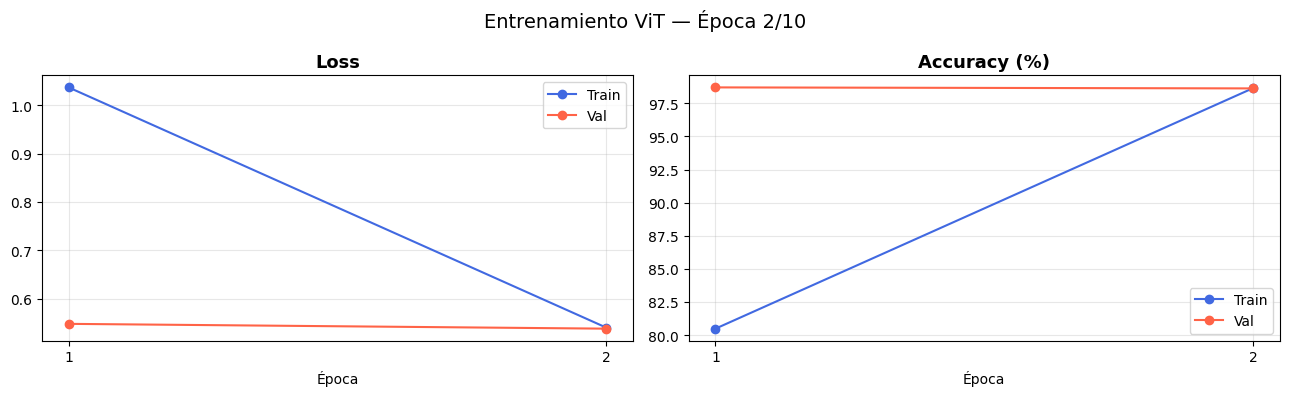

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Checkpoint guardado (val_loss=0.5376)


Época  3/10 | Train → loss: 0.5279  acc: 98.96% | Val   → loss: 0.5336  acc: 98.70% | ⏱ 209s


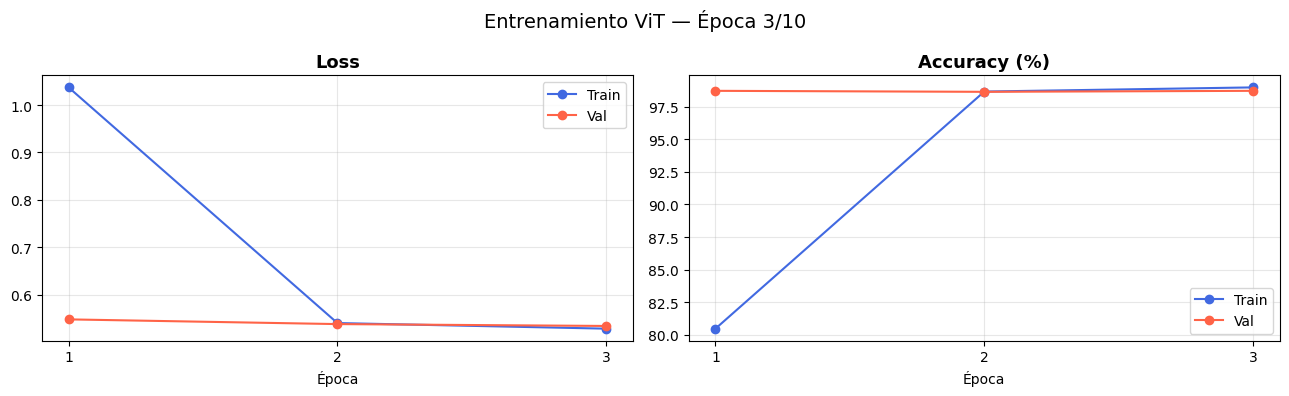

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Checkpoint guardado (val_loss=0.5336)


Época  4/10 | Train → loss: 0.5228  acc: 99.18% | Val   → loss: 0.5335  acc: 98.82% | ⏱ 201s


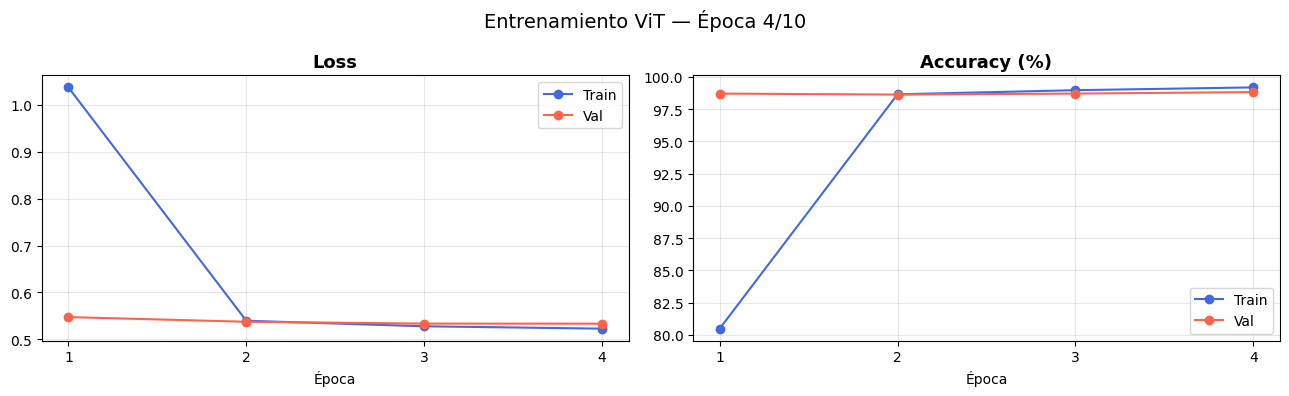

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Checkpoint guardado (val_loss=0.5335)


Época  5/10 | Train → loss: 0.5208  acc: 99.28% | Val   → loss: 0.5340  acc: 98.78% | ⏱ 202s


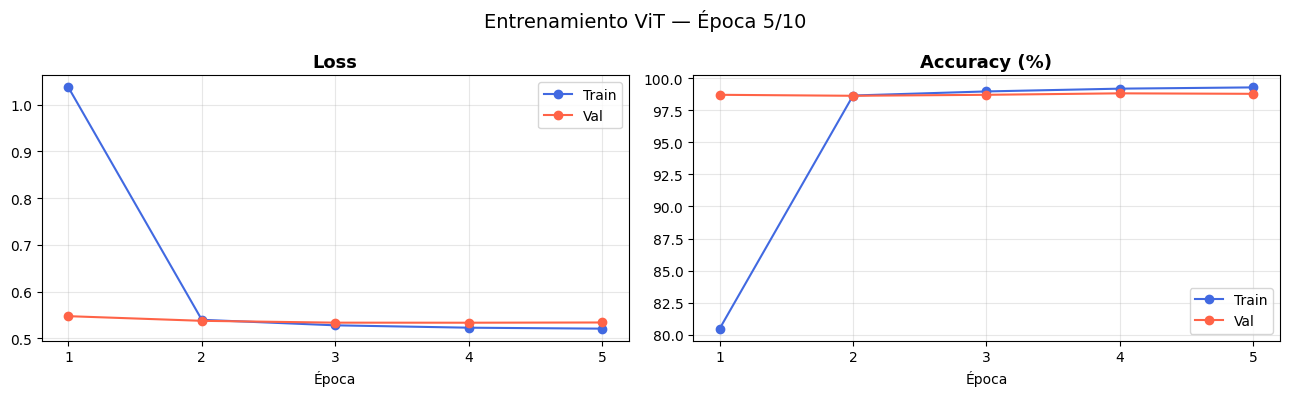

   ⏳ Sin mejora 1/3


Época  6/10 | Train → loss: 0.5201  acc: 99.35% | Val   → loss: 0.5340  acc: 98.82% | ⏱ 202s


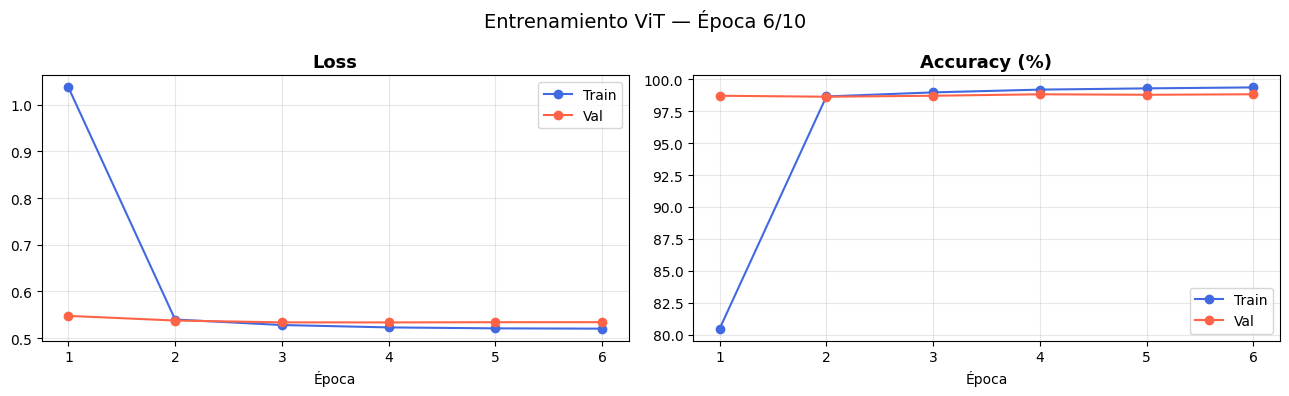

   ⏳ Sin mejora 2/3


Época  7/10 | Train → loss: 0.5174  acc: 99.39% | Val   → loss: 0.5346  acc: 98.74% | ⏱ 201s


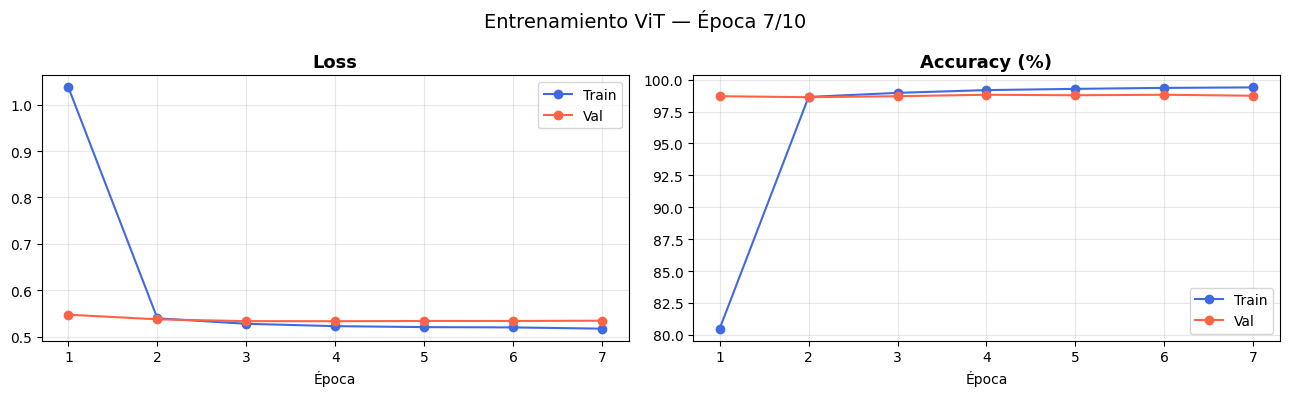

   ⏳ Sin mejora 3/3

🛑 Early stopping. Mejor época: 4

✅ Entrenamiento completado en 24.8 min


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Modelo guardado en : /content/my_vit_animals10
   Mejor época        : 4
   Mejor val_loss     : 0.5335
   Mejor val_acc      : 98.82%


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from transformers import ViTImageProcessor, ViTForImageClassification, get_linear_schedule_with_warmup
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, time

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────
MODEL_NAME      = "google/vit-base-patch16-224"
DATA_DIR        = "/content/animals10/normalized-224"
CHECKPOINT_DIR  = "/content/checkpoints"
FINAL_MODEL_DIR = "/content/my_vit_animals10"

NUM_CLASSES  = 10
BATCH_SIZE   = 32
EPOCHS       = 10
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
TRAIN_RATIO  = 0.9
FROZEN_LAYERS = 6
PATIENCE     = 3
MIN_DELTA    = 1e-4

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

os.makedirs(CHECKPOINT_DIR,  exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

print(f"✅ Dispositivo : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU          : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"   AMP          : {USE_AMP}")

# ─────────────────────────────────────────────────────────────────────────────
#  DATASET
# ─────────────────────────────────────────────────────────────────────────────
processor  = ViTImageProcessor.from_pretrained(MODEL_NAME)
IMAGE_SIZE = processor.size if isinstance(processor.size, int) \
             else processor.size.get("shortest_edge", 224)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

full_train  = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_val    = datasets.ImageFolder(DATA_DIR, transform=val_transform)
CLASS_NAMES = full_train.classes

n_total = len(full_train)
n_train = int(TRAIN_RATIO * n_total)
indices = torch.randperm(n_total).tolist()

train_loader = DataLoader(Subset(full_train, indices[:n_train]),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(Subset(full_val, indices[n_train:]),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print(f"\n✅ Dataset      : {n_total:,} imágenes → Train {n_train:,} | Val {n_total-n_train:,}")
print(f"   Clases       : {CLASS_NAMES}")

# ─────────────────────────────────────────────────────────────────────────────
#  MODELO
# ─────────────────────────────────────────────────────────────────────────────
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
    id2label={i: c for i, c in enumerate(CLASS_NAMES)},
    label2id={c: i for i, c in enumerate(CLASS_NAMES)},
).to(DEVICE)

for layer in model.vit.encoder.layer[:FROZEN_LAYERS]:
    for p in layer.parameters():
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\n✅ Parámetros   : {trainable:,} / {total:,}  ({100*trainable/total:.1f}% entrenables)")

optimizer = AdamW([
    {"params": model.vit.encoder.layer[FROZEN_LAYERS:].parameters(), "lr": LR},
    {"params": model.classifier.parameters(), "lr": LR * 5},
], weight_decay=WEIGHT_DECAY)

num_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * num_steps),
    num_training_steps=num_steps,
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = GradScaler(enabled=USE_AMP)

# ─────────────────────────────────────────────────────────────────────────────
#  EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience, min_delta, path):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.best_loss  = float("inf")
        self.best_epoch = 0
        self.counter    = 0

    def step(self, val_loss, model, processor, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_epoch = epoch
            self.counter    = 0
            model.save_pretrained(self.path)
            processor.save_pretrained(self.path)
            print(f"   💾 Checkpoint guardado (val_loss={val_loss:.4f})")
            return False
        self.counter += 1
        print(f"   ⏳ Sin mejora {self.counter}/{self.patience}")
        return self.counter >= self.patience

early_stopping = EarlyStopping(PATIENCE, MIN_DELTA, CHECKPOINT_DIR)

# ─────────────────────────────────────────────────────────────────────────────
#  VISUALIZACIÓN
# ─────────────────────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def plot_history(epoch):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    rng = range(1, epoch + 2)
    for ax, (k1, k2), title in zip(
        axes,
        [("train_loss", "val_loss"), ("train_acc", "val_acc")],
        ["Loss", "Accuracy (%)"],
    ):
        ax.plot(rng, history[k1], "o-", label="Train", color="royalblue")
        ax.plot(rng, history[k2], "o-", label="Val",   color="tomato")
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Época")
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f"Entrenamiento ViT — Época {epoch+1}/{EPOCHS}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CHECKPOINT_DIR}/metrics_epoch{epoch+1}.png", dpi=90)
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
#  BUCLE DE ENTRENAMIENTO
# ─────────────────────────────────────────────────────────────────────────────
def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc="Train" if train else "Val  ",
                                   leave=False, unit="batch"):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast(enabled=USE_AMP):
                logits = model(images).logits
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


print("\n🚀 Iniciando entrenamiento...\n")
t_total = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"  ].append(val_loss)
    history["train_acc" ].append(train_acc)
    history["val_acc"   ].append(val_acc)

    print(f"Época {epoch+1:2d}/{EPOCHS} | "
          f"Train → loss: {train_loss:.4f}  acc: {train_acc:.2f}% | "
          f"Val   → loss: {val_loss:.4f}  acc: {val_acc:.2f}% | "
          f"⏱ {time.time()-t0:.0f}s")


    if early_stopping.step(val_loss, model, processor, epoch):
        print(f"\n🛑 Early stopping. Mejor época: {early_stopping.best_epoch+1}")
        break
plot_history(epoch)
print(f"\n✅ Entrenamiento completado en {(time.time()-t_total)/60:.1f} min")

# ─────────────────────────────────────────────────────────────────────────────
#  GUARDAR MODELO FINAL (mejor checkpoint)
# ─────────────────────────────────────────────────────────────────────────────
best_model = ViTForImageClassification.from_pretrained(CHECKPOINT_DIR).to(DEVICE)
best_model.save_pretrained(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)

print(f"\n✅ Modelo guardado en : {FINAL_MODEL_DIR}")
print(f"   Mejor época        : {early_stopping.best_epoch+1}")
print(f"   Mejor val_loss     : {early_stopping.best_loss:.4f}")
print(f"   Mejor val_acc      : {max(history['val_acc']):.2f}%")

In [ ]:
model.save_pretrained("./model_vit_animals")       # folder with: config.json, pytorch_model.bin, etc.
processor.save_pretrained("./model_vit_animals")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./model_vit_animals/preprocessor_config.json']